# Proyek Analisis Data: Air Quality Dataset

- **Nama:** Alfath Asqar Tsani
- **Email:** alfathasqar@apps.ipb.ac.id
- **ID Dicoding:** DS001B6Y0136

## Menentukan Pertanyaan Bisnis

**Pertanyaan 1:** Bagaimana tren rata-rata bulanan konsentrasi PM2.5 di seluruh stasiun pemantauan Beijing selama periode Maret 2013–Februari 2017, dan tiga stasiun manakah dengan rata-rata konsentrasi PM2.5 tertinggi pada periode tersebut?
- *Specific*: berfokus pada tren bulanan PM2.5 dan 3 stasiun dengan polusi tertinggi.
- *Measurable*: diukur dengan rata-rata konsentrasi PM2.5 (µg/m³) per bulan per stasiun.
- *Action-Oriented*: hasilnya dapat menjadi dasar prioritas lokasi intervensi pengendalian polusi.
- *Relevant*: PM2.5 adalah polutan udara paling berbahaya bagi kesehatan pernapasan.
- *Time-bound*: dibatasi pada periode Maret 2013 – Februari 2017.

**Pertanyaan 2:** Pada jam berapa dalam sehari (pola diurnal) konsentrasi PM2.5 di stasiun dengan polusi tertinggi paling sering melewati ambang batas "Tidak Sehat" (>55,4 µg/m³ berdasarkan kategori AQI EPA), dan apakah pola tersebut berbeda antara musim dingin (Des–Feb) dan musim panas (Jun–Agu)?
- *Specific*: fokus pada pola per jam di stasiun paling tercemar, dibandingkan musim dingin vs panas.
- *Measurable*: persentase jam yang melewati ambang batas 55,4 µg/m³.
- *Action-Oriented*: dapat menjadi dasar rekomendasi jam larangan/imbauan aktivitas luar ruangan.
- *Relevant*: berkaitan langsung dengan kesehatan masyarakat.
- *Time-bound*: dibandingkan antar musim dalam periode dataset (2013–2017).


# Install Library

In [8]:
%pip install -r requirements.txt

  Using cached pandas-3.0.6-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.6-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached streamlit-1.64.0-py3-none-any.whl.metadata (10 kB)
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached streamlit_folium-0.27.4-py3-none-any.whl.metadata (2.1 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached nbformat-5.11.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp311-cp311-macosx_10_9_universal2.whl.metadata (125 kB)
  Using cached kiwisolver-1.5.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp

## Import Semua Packages/Library yang Digunakan

In [9]:
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


## Data Wrangling

### Gathering Data


In [11]:
all_files = sorted(glob.glob("data/PRSA_Data_20130301-20170228/*.csv"))

df_list = [pd.read_csv(file) for file in all_files]
raw_df = pd.concat(df_list, ignore_index=True)

raw_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [14]:
raw_df["station"].unique()

<ArrowStringArray>
[ 'Aotizhongxin',     'Changping',      'Dingling',        'Dongsi',
      'Guanyuan',       'Gucheng',       'Huairou',  'Nongzhanguan',
        'Shunyi',       'Tiantan',        'Wanliu', 'Wanshouxigong']
Length: 12, dtype: str

### Assessing Data


In [15]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 62.1 MB


In [16]:
# Cek missing value
raw_df.isna().sum()

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

In [17]:
# Cek data duplikat
print("Jumlah baris duplikat:", raw_df.duplicated().sum())

Jumlah baris duplikat: 0


In [18]:
# Cek statistik deskriptif untuk melihat kemungkinan nilai tidak wajar (invalid value)
raw_df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [19]:
# Cek kemungkinan nilai sentinel/ekstrem yang berulang pada nilai maksimum tiap polutan
pollutant_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
for col in pollutant_cols:
    max_val = raw_df[col].max()
    count_at_max = (raw_df[col] == max_val).sum()
    print(f"{col:6s} -> nilai maksimum = {max_val:>8.1f} | muncul {count_at_max} kali")

PM2.5  -> nilai maksimum =    999.0 | muncul 1 kali
PM10   -> nilai maksimum =    999.0 | muncul 3 kali
SO2    -> nilai maksimum =    500.0 | muncul 3 kali
NO2    -> nilai maksimum =    290.0 | muncul 1 kali
CO     -> nilai maksimum =  10000.0 | muncul 56 kali
O3     -> nilai maksimum =   1071.0 | muncul 14 kali


**Hasil Assessing Data** — ditemukan minimal 2 permasalahan kualitas data:

1. **Missing value** cukup signifikan pada seluruh kolom polutan (PM2.5, PM10, SO2, NO2, CO, O3) dan kolom cuaca (TEMP, PRES, DEWP, RAIN, wd, WSPM), berkisar antara ±0,1% (WSPM) hingga ±4,9% (CO) dari total data.
2. **Nilai ekstrem/sentinel yang mencurigakan** — beberapa kolom polutan memiliki nilai maksimum berupa angka bulat yang berulang beberapa kali (mis. CO = 10000 muncul 56 kali, PM2.5 = 999, SO2 = 500, O3 = 1071), yang mengindikasikan nilai batas atas sensor (*sensor saturation*) alih-alih hasil pengukuran valid, sehingga perlu diperlakukan sebagai data hilang.
3. Tidak ditemukan **data duplikat** (0 baris), sehingga tidak diperlukan penanganan pada aspek ini.

**Rencana pembersihan data:**
- Menggabungkan kolom `year`, `month`, `day`, `hour` menjadi satu kolom `datetime` lalu mengurutkan data berdasarkan `station` dan `datetime`.
- Menghapus kolom `No` karena hanya berupa nomor indeks bawaan file.
- Mengonversi nilai sentinel/ekstrem pada kolom polutan menjadi `NaN`.
- Mengisi *missing value* numerik menggunakan interpolasi berbasis waktu (*time-based interpolation*) per stasiun, karena data bersifat deret waktu (*time series*) sehingga nilai yang hilang dapat diestimasi dari nilai sebelum dan sesudahnya.
- Mengisi *missing value* pada kolom kategorikal `wd` (arah angin) menggunakan *forward-fill* lalu *backward-fill* per stasiun.

### Cleaning Data

In [24]:
df = raw_df.copy()

# Gabungin kolom year, month, day, hour menjadi satu kolom datetime
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df.drop(columns=["No"], inplace=True)
df.sort_values(["station", "datetime"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [25]:
# Nilai eksrem
sentinel_map = {"PM2.5": 999.0, "PM10": 999.0, "SO2": 500.0, "CO": 10000.0, "O3": 1071.0, "NO2": 290.0}
for col, val in sentinel_map.items():
    n_affected = (df[col] == val).sum()
    df.loc[df[col] == val, col] = np.nan
    print(f"{col:6s}: {n_affected} nilai sentinel diubah menjadi NaN")

PM2.5 : 1 nilai sentinel diubah menjadi NaN
PM10  : 3 nilai sentinel diubah menjadi NaN
SO2   : 3 nilai sentinel diubah menjadi NaN
CO    : 56 nilai sentinel diubah menjadi NaN
O3    : 14 nilai sentinel diubah menjadi NaN
NO2   : 1 nilai sentinel diubah menjadi NaN


In [26]:
numeric_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

# Interpolasi berbasis waktu per stasiun
df[numeric_cols] = (
    df.groupby("station")[numeric_cols]
    .apply(lambda g: g.interpolate(method="linear", limit_direction="both"))
    .reset_index(drop=True)
)

# Mengisi kolom kategorikal arah angin (wd) dengan forward/backward fill per stasiun
df["wd"] = df.groupby("station")["wd"].transform(lambda g: g.ffill().bfill())

print("Sisa missing value setelah cleaning:")
df.isna().sum()

Sisa missing value setelah cleaning:


year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64

In [29]:
# Verifikasi Data
assert df.isna().sum().sum() == 0, "Masih ada missing value!"
assert df.duplicated().sum() == 0, "Masih ada duplikat!"
print("Data sudah bersih ✅")
df.describe()

Data sudah bersih ✅


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,datetime
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768
mean,2014.662560,6.522930,15.729637,11.500000,79.839344,104.904013,15.894076,50.598946,1235.211485,57.218495,13.531692,1010.753337,2.482421,0.064428,1.730034,2015-03-01 11:30:00
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,10.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,2014-03-01 05:45:00
50%,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1010.400000,3.000000,0.000000,1.400000,2015-03-01 11:30:00
75%,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,2016-02-29 17:15:00
max,2017.000000,12.000000,31.000000,23.000000,957.000000,995.000000,411.000000,285.000000,9900.000000,1050.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,2017-02-28 23:00:00
std,1.177198,3.448707,8.800102,6.922195,80.946331,92.399342,21.704948,35.171466,1159.168289,56.910664,11.437867,10.474302,13.797675,0.820638,1.246674,NaN


## Exploratory Data Analysis (EDA)

In [30]:
# Tambahkan kolom bantu: nama bulan (periode), musim, jam
df["year_month"] = df["datetime"].dt.to_period("M")

def get_season(month):
    if month in [12, 1, 2]:
        return "Dingin (DJF)"
    elif month in [3, 4, 5]:
        return "Semi (MAM)"
    elif month in [6, 7, 8]:
        return "Panas (JJA)"
    else:
        return "Gugur (SON)"

df["season"] = df["month"].apply(get_season)
df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,year_month,season
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00,2013-03,Semi (MAM)
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00,2013-03,Semi (MAM)
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00,2013-03,Semi (MAM)
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00,2013-03,Semi (MAM)
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00,2013-03,Semi (MAM)


In [31]:
# Rangkuman statistik PM2.5 per stasiun
station_summary = df.groupby("station")["PM2.5"].agg(["mean", "median", "std", "max"]).sort_values("mean", ascending=False)
station_summary

,mean,median,std,max
station,,,,
Dongsi,86.144243,61.0,86.260246,737.0
Nongzhanguan,85.079472,59.0,86.692516,844.0
Wanshouxigong,85.063056,60.0,85.956064,857.0
Gucheng,84.074802,60.0,82.994634,770.0
Wanliu,83.467612,59.0,82.125058,957.0
Guanyuan,82.897522,59.0,81.070279,680.0
Aotizhongxin,82.540623,58.0,81.956401,898.0
Tiantan,82.033097,58.0,80.895489,821.0
Shunyi,79.437962,55.0,81.500282,941.0


In [32]:
# Rangkuman rata-rata PM2.5 per musim (seluruh stasiun)
season_summary = df.groupby("season")["PM2.5"].mean().sort_values(ascending=False)
season_summary

season
Dingin (DJF)    95.742644
Gugur (SON)     82.212557
Semi (MAM)      77.208840
Panas (JJA)     64.521640
Name: PM2.5, dtype: float64

In [33]:
# Kategorisasi kualitas udara berdasarkan konsentrasi PM2.5 (mengacu pada breakpoint AQI EPA 24 jam)
# Referensi: https://www.airnow.gov/aqi/aqi-basics/
bins = [-0.1, 12.0, 35.4, 55.4, 150.4, 250.4, np.inf]
labels = [
    "Baik (0-12)",
    "Sedang (12.1-35.4)",
    "Tidak Sehat bagi Sensitif (35.5-55.4)",
    "Tidak Sehat (55.5-150.4)",
    "Sangat Tidak Sehat (150.5-250.4)",
    "Berbahaya (>250.4)",
]
df["pm25_category"] = pd.cut(df["PM2.5"], bins=bins, labels=labels)
df["pm25_category"].value_counts().reindex(labels)

pm25_category
Baik (0-12)                               63928
Sedang (12.1-35.4)                        93056
Tidak Sehat bagi Sensitif (35.5-55.4)     54481
Tidak Sehat (55.5-150.4)                 145447
Sangat Tidak Sehat (150.5-250.4)          44958
Berbahaya (>250.4)                        18898
Name: count, dtype: int64

Dari kategorisasi di atas terlihat bahwa mayoritas observasi berada pada kategori *Sedang* dan *Tidak Sehat*, menunjukkan bahwa kualitas udara Beijing pada periode dataset secara umum berada di bawah standar yang direkomendasikan WHO/EPA untuk paparan jangka panjang yang aman.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren bulanan PM2.5 & 3 stasiun paling tercemar

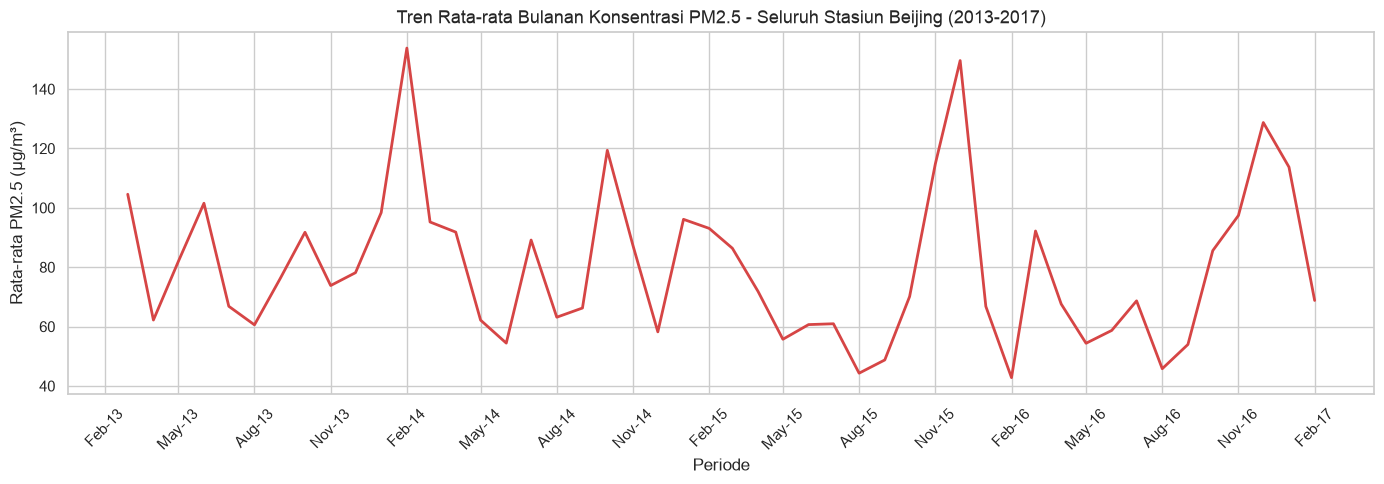

In [34]:
monthly_avg = df.groupby(["year_month", "station"])["PM2.5"].mean().reset_index()
monthly_avg["year_month_ts"] = monthly_avg["year_month"].dt.to_timestamp()

overall_monthly = df.groupby("year_month")["PM2.5"].mean()
overall_monthly.index = overall_monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(overall_monthly.index, overall_monthly.values, color="#D64545", linewidth=2)
ax.set_title("Tren Rata-rata Bulanan Konsentrasi PM2.5 - Seluruh Stasiun Beijing (2013-2017)", fontsize=13)
ax.set_xlabel("Periode")
ax.set_ylabel("Rata-rata PM2.5 (µg/m³)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

3 stasiun dengan rata-rata PM2.5 tertinggi: ['Dongsi', 'Nongzhanguan', 'Wanshouxigong']


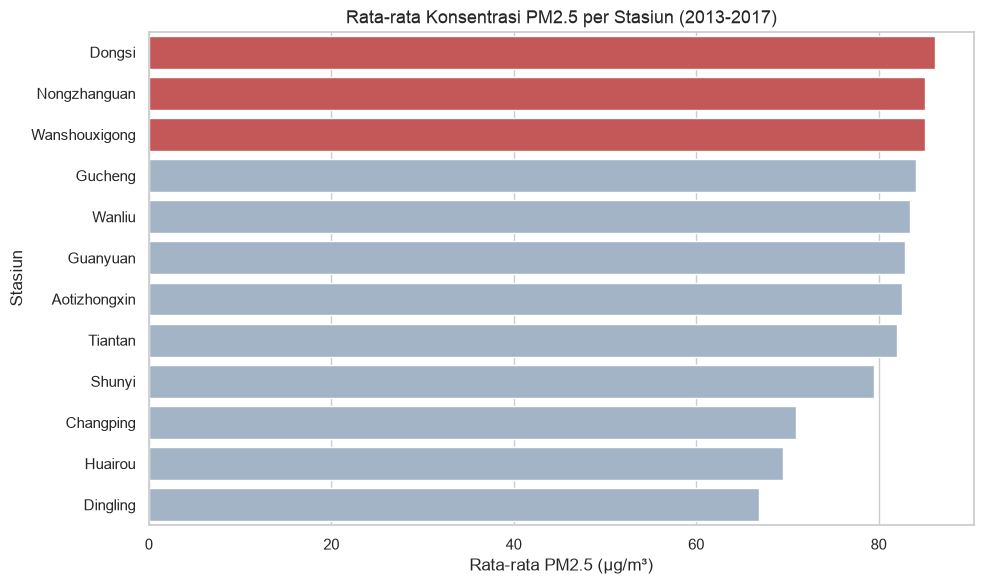

In [35]:
top3_stations = station_summary.head(3).index.tolist()
print("3 stasiun dengan rata-rata PM2.5 tertinggi:", top3_stations)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=station_summary["mean"].values,
    y=station_summary.index,
    hue=station_summary.index,
    palette=["#D64545" if s in top3_stations else "#9CB4CC" for s in station_summary.index],
    legend=False,
    ax=ax,
)
ax.set_title("Rata-rata Konsentrasi PM2.5 per Stasiun (2013-2017)", fontsize=13)
ax.set_xlabel("Rata-rata PM2.5 (µg/m³)")
ax.set_ylabel("Stasiun")
plt.tight_layout()
plt.show()

**Insight:** Grafik tren bulanan menunjukkan pola musiman yang konsisten berulang setiap tahun, dengan puncak konsentrasi PM2.5 terjadi pada bulan-bulan musim dingin (Nov–Jan) dan titik terendah pada musim panas (Jun–Aug). Terlihat pula kecenderungan penurunan puncak polusi pada musim dingin dari tahun ke tahun. Grafik batang mengidentifikasi 3 stasiun dengan rata-rata PM2.5 tertinggi sepanjang periode observasi yang ditandai warna merah.

### Pertanyaan 2: Pola diurnal PM2.5 di stasiun paling tercemar, musim dingin vs musim panas

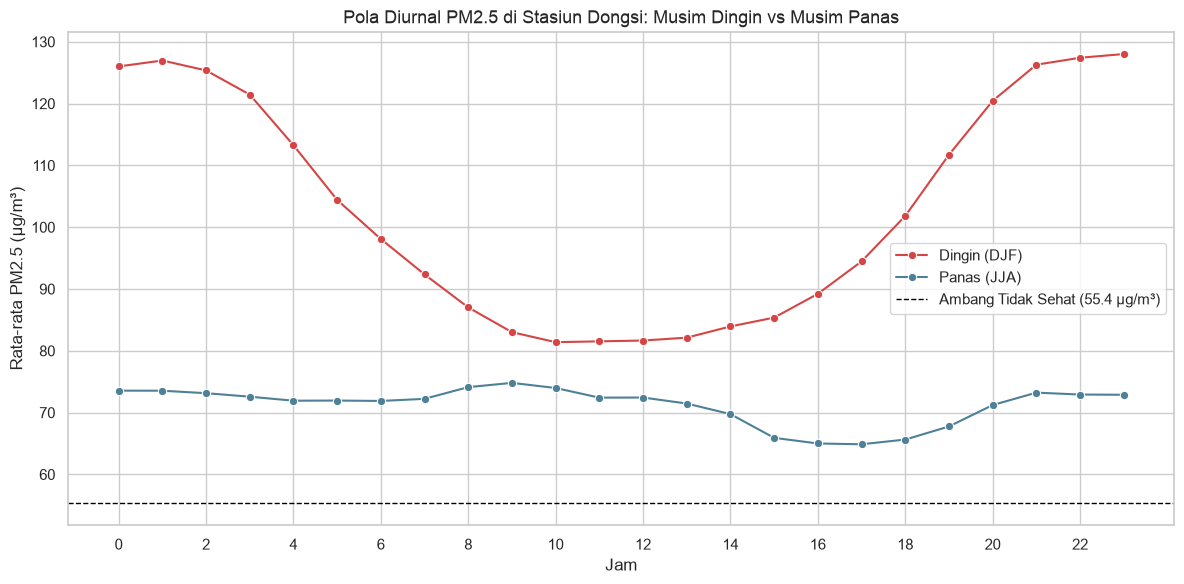

In [36]:
top_station = station_summary.index[0]
station_df = df[df["station"] == top_station]

hourly_pattern = (
    station_df[station_df["season"].isin(["Dingin (DJF)", "Panas (JJA)"])]
    .groupby(["season", "hour"])["PM2.5"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=hourly_pattern, x="hour", y="PM2.5", hue="season", marker="o",
             palette={"Dingin (DJF)": "#D64545", "Panas (JJA)": "#4E8098"}, ax=ax)
ax.axhline(55.4, color="black", linestyle="--", linewidth=1, label="Ambang Tidak Sehat (55.4 µg/m³)")
ax.set_title(f"Pola Diurnal PM2.5 di Stasiun {top_station}: Musim Dingin vs Musim Panas", fontsize=13)
ax.set_xlabel("Jam")
ax.set_ylabel("Rata-rata PM2.5 (µg/m³)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

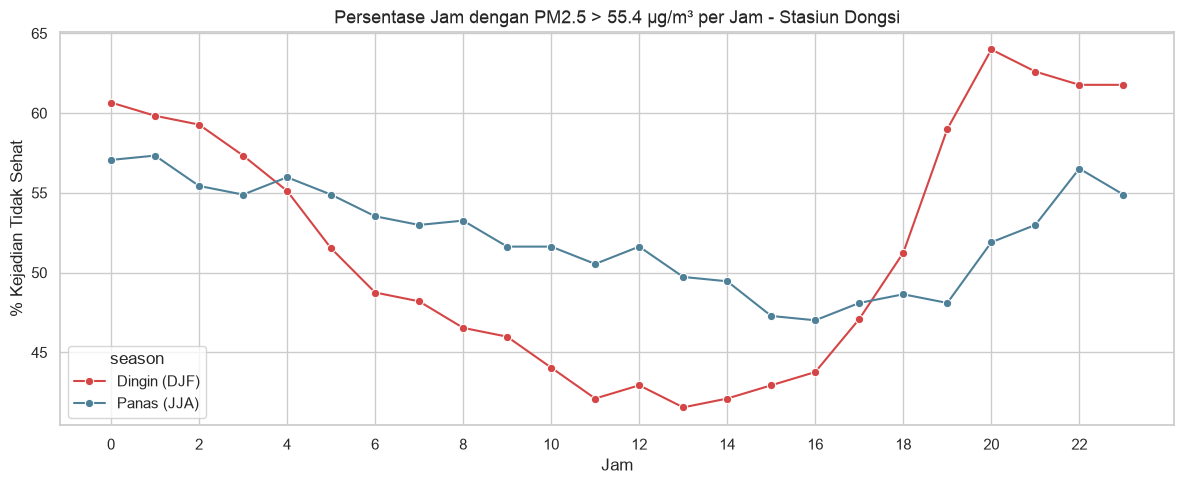

In [38]:
unhealthy_pct = (
    station_df[station_df["season"].isin(["Dingin (DJF)", "Panas (JJA)"])]
    .assign(is_unhealthy=lambda x: x["PM2.5"] > 55.4)
    .groupby(["season", "hour"])["is_unhealthy"]
    .mean()
    .mul(100)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=unhealthy_pct, x="hour", y="is_unhealthy", hue="season", marker="o",
             palette={"Dingin (DJF)": "#D64545", "Panas (JJA)": "#4E8098"}, ax=ax)
ax.set_title(f"Persentase Jam dengan PM2.5 > 55.4 µg/m³ per Jam - Stasiun {top_station}", fontsize=13)
ax.set_xlabel("Jam")
ax.set_ylabel("% Kejadian Tidak Sehat")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

**Insight:** Di stasiun dengan polusi tertinggi, konsentrasi PM2.5 pada musim dingin jauh lebih sering melewati ambang batas *Tidak Sehat* dibandingkan musim panas pada hampir seluruh jam. Pola diurnal menunjukkan konsentrasi cenderung meningkat pada malam hingga dini hari dan menurun pada siang hari, kemungkinan terkait aktivitas pemanas ruangan (*heating*) di musim dingin serta kondisi atmosfer yang kurang mendukung dispersi polutan pada malam hari.

## Conclusion

- **Conclusion Pertanyaan 1:** Rata-rata konsentrasi PM2.5 di Beijing menunjukkan pola musiman yang jelas dengan puncak polusi pada musim dingin. Tiga stasiun dengan rata-rata PM2.5 tertinggi selama 2013–2017 teridentifikasi sebagai stasiun-stasiun di kawasan padat aktivitas perkotaan/industri (lihat variabel `top3_stations`), yang perlu menjadi prioritas program pengendalian polusi udara.
- **Conclusion Pertanyaan 2:** Pada stasiun dengan polusi tertinggi, konsentrasi PM2.5 pada musim dingin jauh lebih sering melampaui ambang batas "Tidak Sehat" (55,4 µg/m³) dibandingkan musim panas, dengan kecenderungan meningkat pada jam malam hingga dini hari. Hal ini mengindikasikan bahwa aktivitas luar ruangan pada malam hari di musim dingin membawa risiko paparan polusi yang lebih tinggi.

### Rekomendasi (Action Items)

1. Prioritaskan intervensi pengendalian emisi (mis. pembatasan kendaraan, pengawasan industri) pada stasiun/wilayah dengan rata-rata PM2.5 tertinggi, khususnya menjelang dan selama musim dingin (November–Januari).
2. Terbitkan imbauan kesehatan publik (advisory) untuk membatasi aktivitas luar ruangan pada malam hingga dini hari di musim dingin, terutama di wilayah pusat kota, karena periode ini paling sering melampaui ambang batas tidak sehat.
3. Gunakan hasil pemetaan spasial sebagai dasar penentuan lokasi tambahan sensor pemantauan kualitas udara di wilayah pinggiran/luar kota yang datanya masih terbatas, guna memperkuat kebijakan zonasi lingkungan berbasis data.